# Visualisation des Datas et Résultats du réseau de diffusion.

## Verification du Dataset
On cherche ici a verifier que les images sont bien visuellement conforme a ce qui a été montré dans le notebook [VisualisationSim](VisualisationSim.ipynb), mais également la repartition des pixels.

In [2]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

import sys
from pathlib import Path

# Ajoute la racine du projet
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from diffusion_lib.DDPM import DDPM
from diffusion_lib.UNet import UNet

In [3]:
# Paths (ajuster si besoin)
DATA_ROOT = "../data/RT28"  # ou data/MNIST
TRAIN_PT = os.path.join(DATA_ROOT, "processed", "training2.pt")
TEST_PT = os.path.join(DATA_ROOT, "processed", "test.pt")
VAL_PT = os.path.join(DATA_ROOT, "processed", "validation.pt")

In [3]:
def load_pt_dataset(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Fichier introuvable: {path}")
    loaded = torch.load(path)
    return loaded

def show_grid(images, n=16, cols=4, cmap="gray", seed=None):
    rows = int(np.ceil(n / cols))
    rng = np.random.default_rng(seed)
    total = images.shape[0]
    n = min(n, total)
    indices = rng.choice(total, size=n, replace=False)
    plt.figure(figsize=(cols * 2.2, rows * 2.2))
    for i, idx in enumerate(indices):
        ax = plt.subplot(rows, cols, i + 1)
        img = images[idx].numpy() if torch.is_tensor(images) else images[idx]
        if img.ndim == 3 and img.shape[0] == 1:
            img = img[0]
        ax.imshow(img, cmap=cmap)
        ax.set_title(f"idx={idx}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [4]:
train_images = load_pt_dataset(TRAIN_PT)
test_images = load_pt_dataset(TEST_PT)

print("Train images", train_images.shape, train_images.dtype)
print("Test images", test_images.shape, test_images.dtype)

Train images torch.Size([52224, 28, 28]) torch.uint8
Test images torch.Size([327, 28, 28]) torch.uint8


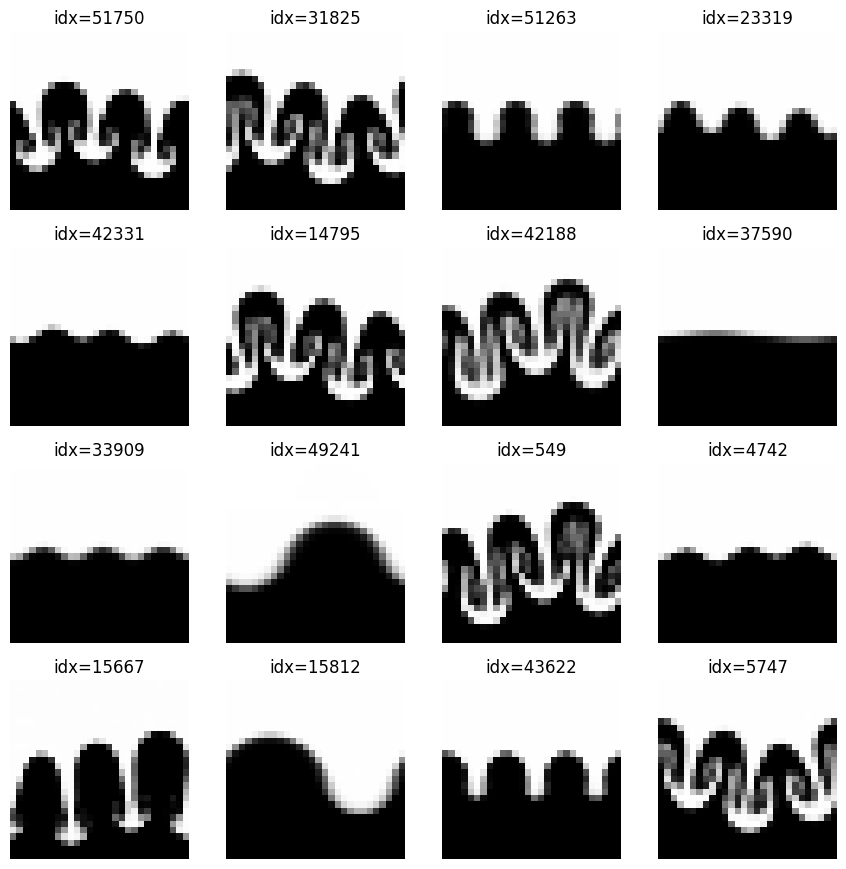

In [5]:
show_grid(train_images, n=16, cols=4)

## Infomration sur l'entrainement

In [6]:
def plot_loss_curve(csv_path):
    data = np.genfromtxt(csv_path, delimiter=",", names=True, dtype=None, encoding="utf-8")
    if "epoch" not in data.dtype.names or "loss" not in data.dtype.names:
        raise ValueError("Le CSV doit contenir les colonnes 'epoch' et 'loss'.")

    epochs = data["epoch"]
    loss = data["loss"]
    best_loss = data["best_loss"] if "best_loss" in data.dtype.names else None

    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].plot(epochs, loss, label="loss")
    if best_loss is not None:
        ax[0].plot(epochs, best_loss, label="best_loss", alpha=0.8)
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_title("RT28 loss")
    ax[0].legend()

    eps = 1e-12
    ax[1].plot(epochs, np.log(np.clip(loss, eps, None)), label="log(loss)")
    if best_loss is not None:
        ax[1].plot(epochs, np.log(np.clip(best_loss, eps, None)), label="log(best_loss)", alpha=0.8)
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Log loss")
    ax[1].set_title("RT28 log loss")
    ax[1].legend()

    fig.tight_layout()
    plt.show()

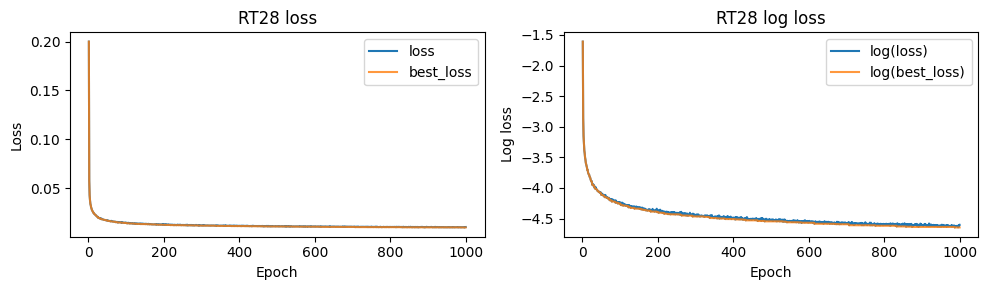

In [7]:
csv_path = "res/RT28-1000.csv"
plot_loss_curve(csv_path)

## Visualisation des résultats

In [8]:
MODEL_PT = "res/RT28-1000.pt"
DEVICE = "cpu"

# Ajuster ces hyperparametres si le modele a ete entraine avec d'autres valeurs
N_STEPS = 1000
TIME_EMB_DIM = 100
MIN_BETA = 1e-4
MAX_BETA = 0.02

In [9]:
state = torch.load(MODEL_PT, map_location=DEVICE)
if isinstance(state, dict) and not hasattr(state, "image_chw"):
    ddpm = DDPM(
        UNet(n_steps=N_STEPS, time_emb_dim=TIME_EMB_DIM),
        n_steps=N_STEPS,
        min_beta=MIN_BETA,
        max_beta=MAX_BETA,
        device=DEVICE,
    )
    ddpm.load_state_dict(state)
else:
    ddpm = state

if hasattr(ddpm, "to"):
    ddpm = ddpm.to(DEVICE)
ddpm.eval(); # Le ; est pour éviter un warning de PyTorch sur le mode evaluation

In [10]:
def load_pt_results(ddpm, device, n_samples=8):
    """
    Permet de générer des images à partir d'un modèle DDPM et de les retourner sous forme de tenseur.

    Args:
        ddpm: Modèle DDPM utilisé pour la génération.
        device: Périphérique sur lequel générer les images.
        n_samples (int, optional): Nombre d'images a generer. Par défaut à 8.
    """

    # On génère pas à pas et on snapshote a t finale.
    c, h, w = ddpm.image_chw
    x = torch.randn(n_samples, c, h, w).to(device)

    with torch.no_grad():
        for idx, t in enumerate(list(range(ddpm.n_steps))[::-1]):
            time_tensor = (torch.ones(n_samples, 1) * t).to(device).long()
            eta_theta = ddpm.backward(x, time_tensor)
            alpha_t, alpha_t_bar = ddpm.alphas[t], ddpm.alpha_bars[t]
            x = (1 / alpha_t.sqrt()) * (x - (1 - alpha_t) / (1 - alpha_t_bar).sqrt() * eta_theta)
            if t > 0:
                x = x + ddpm.betas[t].sqrt() * torch.randn_like(x)
            step_pct = t / ddpm.n_steps
            images = x.cpu()

    return images

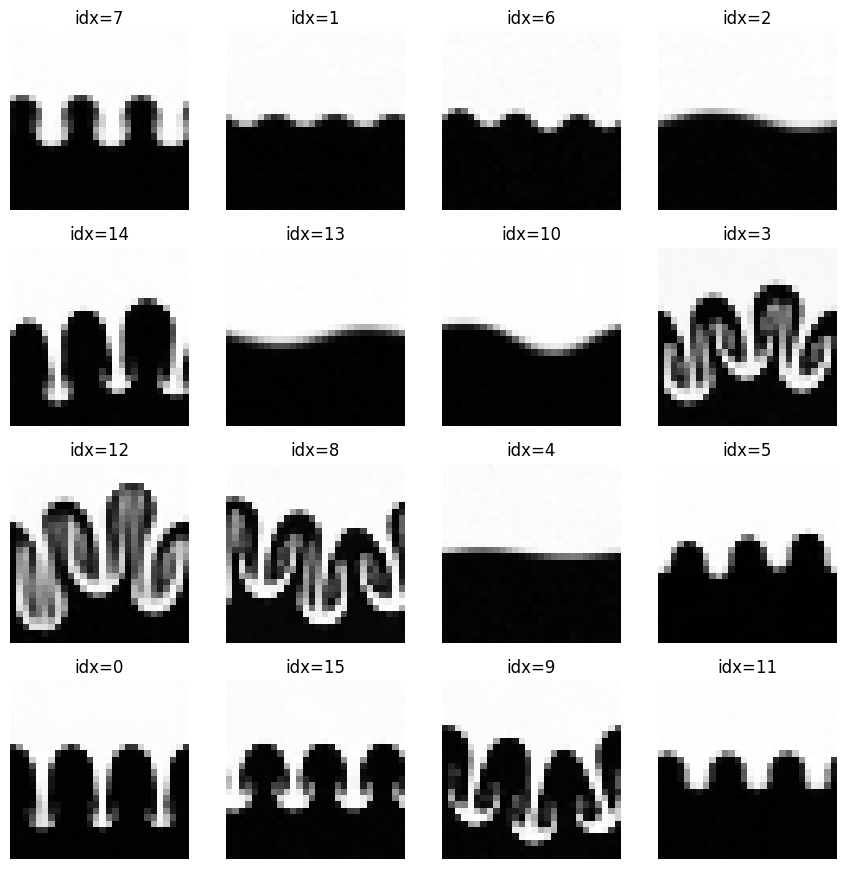

In [11]:
result_images = load_pt_results(ddpm, device="cpu", n_samples=16)
show_grid(result_images, n=16, cols=4)

## PhyFID

PhyFID apprend un encodeur sur `TRAIN_PT`, sauvegarde cet encodeur, puis compare `VAL_PT` et `result_set` dans l'espace de features appris. Au premier lancement, le notebook cree `res/phyfid_encoder.pt` et `res/phyfid_val_stats.npz`; ensuite ces fichiers sont simplement recharges.


In [4]:
from PhyFID.utils import* 

PHYFID_DEMO_ENCODER = "out/phyfid_demo_encoder.pt"
PHYFID_DEMO_STATS = "out/phyfid_demo_val_stats.npz"
PHYFID_DEMO_EPOCHS = 2
PHYFID_DEMO_FEATURE_DIM = 32
PHYFID_DEMO_BATCH_SIZE = 128

MAX_DEMO_TRAIN_SIZE = 1024
MAX_EVAL_SIZE = 100

phyfid_demo_device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
def generate_ddpm_dataset(model, n_samples=100):
    """
    Petite fonction separee pour produire un dataset avec le DDPM du notebook.

    Elle est volontairement hors de PhyFID: c'est une source possible d'images,
    mais la metrique peut comparer n'importe quel dataset deja disponible.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Generation des images avec le DDPM...")
    return load_pt_results(model, device=device, n_samples=n_samples)


In [5]:
build_phyfid_reference(
    dataset_train_path=TRAIN_PT,
    dataset_val_path=VAL_PT,
    encoder_path=PHYFID_DEMO_ENCODER,
    stats_path=PHYFID_DEMO_STATS,
    train_epochs=PHYFID_DEMO_EPOCHS,
    feature_dim=PHYFID_DEMO_FEATURE_DIM,
    batch_size=PHYFID_DEMO_BATCH_SIZE,
    max_train_size=MAX_DEMO_TRAIN_SIZE,
    max_val_size=MAX_EVAL_SIZE,
)


Chargement des datasets de reference...
Preparation des sous-ensembles...
Entrainement de l'encodeur PhyFID...
Epoch 001/2 - reconstruction_loss=0.218301
Epoch 002/2 - reconstruction_loss=0.120962
Sauvegarde de l'encodeur...
Sauvegarde des statistiques de VAL_PT...


('out/phyfid_demo_encoder.pt', 'out/phyfid_demo_val_stats.npz')

In [8]:
generated_dataset = generate_ddpm_dataset(ddpm, n_samples=MAX_EVAL_SIZE)

phyfid_score = evaluate_phyfid_dataset(
    generated_dataset,
    encoder_path=PHYFID_DEMO_ENCODER,
    stats_path=PHYFID_DEMO_STATS,
    batch_size=PHYFID_DEMO_BATCH_SIZE,
)


NameError: name 'ddpm' is not defined